In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import pickle

import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da 

import h5py
import hdf5storage


from skimage import exposure
import matplotlib.pyplot as plt
#from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians

In [38]:
channel_to_detect = 1

# /Volumes/ActiveNAS/Valerie/TransferFolder/20260102_6hIntervals/78h/20251120_78h_SlideB3_Channel1-01_processed_analysis/alphatests
# /Volumes/ActiveNAS/Valerie/TransferFolder/20260102_6hIntervals/78h/20251120_78h_SlideB3_Channel1-01_processed_analysis/zarr_file/all_channels_data
# /Volumes/ActiveNAS/Valerie/TransferFolder/20260102_6hIntervals/78h/20251120_78h_SlideB3_Channel1-01_processed_analysis/alphatests/ch1_01/detection
#/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-Lattice Lightsheet-03_analysis

# Define the file directories (change these to reflect your directories)
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20260130_ArpC3Comparison/20240603_MA2_Plate1-03-Lattice Lightsheet-03_analysis/'
zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'

zarr_full_path = os.path.join(base_dir, zarr_file_directory)

print('Zarr file path:', zarr_full_path)

Zarr file path: /Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-Lattice Lightsheet-03_analysis/zarr_file/all_channels_data


In [7]:
z2 = zarr.open(zarr_full_path, mode='r') 

In [ ]:
# def load_matlab_v73(filename):
#     """
#     Load MATLAB v7.3 file using h5py and convert to dictionary format
#     """
#     def extract_data(obj):
#         """Recursively extract data from h5py objects"""
#         if isinstance(obj, h5py.Dataset):
#             data = obj[()]
#             # Handle MATLAB's way of storing strings
#             if data.dtype.kind == 'O':  # Object array (often strings)
#                 return data
#             return data
#         elif isinstance(obj, h5py.Group):
#             return {key: extract_data(obj[key]) for key in obj.keys()}
#         else:
#             return obj
    
#     with h5py.File(filename, 'r') as f:
#         return {key: extract_data(f[key]) for key in f.keys()}

In [23]:
# # Load the detections - automatically handles both old and new MATLAB formats
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'alphatests/ch1_01/detection/channel_1.mat'
# print(path_to_detections)

# try:
#     # Try old format first (faster if it works)
#     from scipy.io import loadmat
#     detections_dict = loadmat(path_to_detections)
#     print("✓ Loaded using MATLAB v5-v7.2 format")
# except NotImplementedError:
#     # Use HDF5 reader for v7.3 files
#     detections_dict = load_matlab_v73(path_to_detections)
#     print("✓ Loaded using MATLAB v7.3 format (HDF5)")

# # Show what keys are available
# print("Keys in detections_dict:", list(detections_dict.keys()))

/Volumes/ActiveNAS/Valerie/TransferFolder/20260102_6hIntervals/78h/20251120_78h_SlideB3_Channel1-01_processed_analysis/alphatests/ch1_01/detection/channel_1.mat
✓ Loaded using MATLAB v7.3 format (HDF5)
Keys in detections_dict: ['#refs#', '#subsystem#', 'debugPos', 'labelSegPos', 'movieInfo', 'sigmaUsed']


In [9]:
# OLD DETECTION LOADING CODE - KEEP FOR REFERENCE
# Load the detections
 # path_to_detections = os.path.join(base_dir, input_file_directory) + 'output/uTrack3DPackage/detect3D/channel_3.mat'
path_to_detections = os.path.join(base_dir, input_file_directory) + 'ch1/detection/channel_1.mat'

# print(path_to_detections)
# # path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection_results/channel_1.mat'

# detections_dict = loadmat(path_to_detections)

detections_dict = hdf5storage.loadmat(path_to_detections)


In [10]:
# Get the key for your detections
key = 'movieInfo'  # Replace with your actual key name
detection_data = detections_dict[key]

# Create an empty list to store all detections
all_detections = []

# Helper function to safely extract array data
def extract_array(field):
    """Extract data from potentially nested arrays"""
    if field.size == 0:
        return np.array([])
    
    # Handle different possible structures
    if field.dtype.names is not None:
        field = field[0]
    
    if isinstance(field, np.ndarray) and field.size == 1:
        field = field[0]
        
    return field

# Loop through each frame
for frame_idx in range(detection_data.shape[0]):
    try:
        # Get current frame data
        frame_data = detection_data[frame_idx, 0]
        
        # Skip frames with no detections
        if frame_data.size == 0 or 'xCoord' not in frame_data.dtype.names:
            print(f"Skipping frame {frame_idx} due to missing data")
            continue
            
        # Extract arrays for each field
        x_coords = extract_array(frame_data['xCoord'])
        y_coords = extract_array(frame_data['yCoord'])
        z_coords = extract_array(frame_data['zCoord'])
        amp_vals = extract_array(frame_data['amp'])
        int_vals = extract_array(frame_data['int'])

       
        
        # Skip if any arrays are empty
        if any(arr.size == 0 for arr in [x_coords, y_coords, z_coords, amp_vals, int_vals]):
            print(f"Skipping frame {frame_idx} due to empty detection arrays")
            continue
            
        # Determine number of detections in this frame
        num_detections = x_coords.shape[0]

        # Go through num_detections and print if any of x_coords[i][0] is NaN
        for i in range(num_detections):
            if np.isnan(x_coords[i][0]) or np.isnan(y_coords[i][0]) or np.isnan(z_coords[i][0]):
                print(f"Frame {frame_idx}, Detection {i}: NaN value found in coordinates")
                


        # For each detection in this frame
        for i in range(num_detections):
                
                # Skip detection if any value is NaN
                if np.isnan(x_coords[i][0]) or np.isnan(y_coords[i][0]) or np.isnan(z_coords[i][0]):
                    continue

                # mu_x = round(x_coords[i][0]) if len(x_coords[i]) > 0 else np.nan
                # mu_y = round(y_coords[i][0]) if len(y_coords[i]) > 0 else np.nan
                # mu_z = round(z_coords[i][0]) if len(z_coords[i]) > 0 else np.nan
                # amplitude = round(amp_vals[i][0]) if len(amp_vals[i]) > 0 else np.nan
                # intensity = round(int_vals[i][0]) if len(int_vals[i]) > 0 else np.nan

                # detection = {
                #     'frame': frame_idx,  # 1-based frame indexing
                #     'mu_x': mu_x,
                #     'mu_y': mu_y,
                #     'mu_z': mu_z,
                #     'amplitude': amplitude,
                #     'intensity': intensity,
                # }
                detection = {
                    'frame': frame_idx,  # 1-based frame indexing
                    'mu_x': (x_coords[i][0]-1) if len(x_coords[i]) > 0 else np.nan,
                    'mu_y': (y_coords[i][0]-1) if len(y_coords[i]) > 0 else np.nan,
                    'mu_z': (z_coords[i][0]-1) if len(z_coords[i]) > 0 else np.nan,
                    'amplitude': (amp_vals[i][0]) if len(amp_vals[i]) > 0 else np.nan, # Returning a background corrected background
                    'intensity': (int_vals[i][0]) if len(int_vals[i]) > 0 else np.nan,
                }

            
            
            # Add confidence values if available
                if len(x_coords[i]) > 1:
                    detection.update({
                        'x_conf': x_coords[i][1],
                        'y_conf': y_coords[i][1],
                        'z_conf': z_coords[i][1],
                        'amp_conf': amp_vals[i][1],
                        'int_conf': int_vals[i][1],
                    })
                    
                all_detections.append(detection)
    except Exception as e:
        print(f"Error processing frame {frame_idx}: {e}")
        continue

# Create DataFrame from all detections
df = pd.DataFrame(all_detections).set_index('frame')

# Add 3 columns, sigma_x, sigma_y, and sigma_z, such that sigma_x = sigma_y = 2, and sigma_z = 3
df['sigma_x'] = 2
df['sigma_y'] = 2
df['sigma_z'] = 3

# Print summary
if not df.empty:
    print(f"Created DataFrame with {len(df)} total detections across {df.reset_index()['frame'].nunique()} frames")
else:
    print("No detections were found in the data")

Created DataFrame with 244060 total detections across 150 frames


In [18]:
#shape of the zarr array
dask_array = da.from_zarr(z2)
print('Dask array shape:', dask_array.shape)

Dask array shape: (150, 3, 114, 2048, 303)


In [11]:
# # Save df in path_to_detections as a pickle file
output_path = path_to_detections.replace('.mat', '_detections.pkl')
df.to_pickle(output_path)
print(f"Saved detections DataFrame to {output_path}")

Saved detections DataFrame to /Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/ch1/detection/channel_1_detections.pkl


In [ ]:
# If detections have previously been saved, can run this block to load them
# After running the first three blocks
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1_detections.pkl'
# df = pd.read_pickle(path_to_detections).reset_index()

In [12]:
# Visualizing the detections in Napari

# Make a mask of the first time point of the detections

df_reset = df.reset_index()

masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df_reset[df_reset['frame'] == 0])
# masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df)

# Create a napari viewer
viewer = napari.Viewer()

#open the zarr file in read mode
dask_array = da.from_zarr(z2)

# first time point of the zarr file and the channel to detect
#the axis arrangement is (t,c,z,y,x)

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
dask_array_slice = dask_array[0,0,:,:,:]

# Add the 3D stack to the viewer
layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'magenta')

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
# dask_array_slice = dask_array[0,0,:,:,:]

# Add the 3D stack to the viewer
# layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'cyan')

# layer_mask = viewer.add_image(masks, name = 'detections mask')
layer_mask = viewer.add_image(masks, name = 'detections', interpolation3d = 'nearest', blending = 'additive', colormap = 'green')

#other useful parameters 
#color_map = list
#contrast_limits = list of list 

# Add Bounding Box
layer_raw.bounding_box.visible = True

In [29]:
df_reset.head() 

,frame,mu_x,mu_y,mu_z,amplitude,intensity,x_conf,y_conf,z_conf,amp_conf,int_conf,sigma_x,sigma_y,sigma_z
0,0,39.686935,976.981183,19.157310,469.326791,469.326791,0.150201,0.144094,0.184479,32.102335,32.102335,2,2,3
1,0,41.483637,638.269393,20.201685,351.612596,351.612596,0.141753,0.141552,0.182054,23.975383,23.975383,2,2,3
2,0,42.075712,806.875588,20.971878,630.719306,630.719306,0.131419,0.131613,0.166136,39.033397,39.033397,2,2,3
3,0,133.625267,1939.833974,22.072880,149.456214,149.456214,0.122901,0.120063,0.155224,8.532344,8.532344,2,2,3
4,0,43.495524,584.751571,21.378461,526.462829,526.462829,0.123135,0.122936,0.157777,31.217260,31.217260,2,2,3


In [14]:
# Filter for spots in the first frame only
first_frame_spots = df_reset[df_reset['frame'] == 0]

# # Extract coordinates (z, y, x format for napari)
# spots_coords = first_frame_spots[['mu_z', 'mu_y', 'mu_x']].values

# # Generate random colors for each point (RGB values between 0 and 1)
# n_points = len(spots_coords)
# random_colors = np.random.rand(n_points, 3)  # Shape: (n_points, 3) for RGB

# Add to napari viewer
# viewer.add_points(spots_coords, 
#                   name='First Frame Spots',
#                   size=3,  # Adjust size as needed
#                   face_color='random_colors',  # Change color as desired
#                   # edge_color='white'
#                   )

# Extract coordinates (z, y, x format for napari)
spots_coords = first_frame_spots[['mu_z', 'mu_y', 'mu_x']].values

# Generate random colors for each point (RGB values between 0 and 1)
n_points = len(spots_coords)
random_colors = np.random.rand(n_points, 3)  # Shape: (n_points, 3) for RGB

# Add to napari viewer
viewer.add_points(spots_coords, 
                  name='First Frame Spots',
                  size=2,
                  face_color=random_colors,
                  # edge_color='white'
                  )

<Points layer 'First Frame Spots' at 0x13dd47d90>

In [52]:
### ALPHA TESTING VISUALIZATION ###

#Import three different existing pkl files from /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/channel_1_ch3_alpha1_detections.pkl
# df_AP2 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch3_alpha2_detections.pkl').reset_index()
# df_DNM = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch2_alpha2_detections.pkl').reset_index()
# viewer.add_points(df_AP2[df_AP2['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='blue',size=2, name='AP2')
# viewer.add_points(df_DNM[df_DNM['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='red',size=2, name='DNM')

#Import three different existing pkl files from /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/channel_1_ch3_alpha1_detections.pkl
# df_alpha1 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch1_alpha1_detections.pkl').reset_index()
# df_alpha2 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch1_alpha2_detections.pkl').reset_index()
#df_alpha3 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch2_alpha3_detections.pkl').reset_index()

print(input_file_directory)
# Import the three dataframes with different alpha values
df_alpha01 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/ch1_01/detection/channel_1_alpha01_detections.pkl').reset_index()
df_alpha025 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/ch1_025/detection/channel_1_alpha025_detections.pkl').reset_index()
df_alpha05 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/ch1_05/detection/channel_1_alpha05_detections.pkl').reset_index()


#print the size of each dataframe
print(f"Condition 1 detections: {len(df_alpha01)}")
print(f"Condition 2 detections: {len(df_alpha025)}")
print(f"Condition 3 detections: {len(df_alpha05)}")

#Add then first frame spots from df1, df2, and df3 to the napari viewer with different colors
viewer.add_points(df_alpha01[df_alpha01['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='yellow',size=2, name='alpha = 0.01')
viewer.add_points(df_alpha025[df_alpha025['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='cyan',size=2, name = 'alpha = 0.025')
viewer.add_points(df_alpha05[df_alpha05['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='green',size=2, name = 'alpha = 0.05')

20260102_6hIntervals/78h/20251120_78h_SlideB3_Channel1-01_processed_analysis/
Condition 1 detections: 14521
Condition 2 detections: 21249
Condition 3 detections: 40176


<Points layer 'alpha = 0.05' at 0x157c31d50>

In [53]:
#Compare the detection coordinates from df1, df2, and df3 and create a new dataframe with the detections that don't overlap
def get_non_overlapping_detections(df_main, df_compare_list, threshold=3.0):
    """
    Identify detections in df_main that do not overlap with any detections in df_compare_list.
    
    Parameters:
    - df_main: DataFrame containing the main detections to check.
    - df_compare_list: List of DataFrames to compare against.
    - threshold: Distance threshold to consider detections as overlapping.
    
    Returns:
    - DataFrame of non-overlapping detections from df_main.
    """
    # Create a KDTree for each comparison DataFrame
    trees = [cKDTree(df[['mu_x', 'mu_y', 'mu_z']].values) for df in df_compare_list]
    
    non_overlapping_indices = []
    
    for idx, row in df_main.iterrows():
        point = row[['mu_x', 'mu_y', 'mu_z']].values
        is_overlapping = False
        
        # Check against each tree
        for tree in trees:
            distances, _ = tree.query(point, k=1)
            if distances < threshold:
                is_overlapping = True
                break
        
        if not is_overlapping:
            non_overlapping_indices.append(idx)
    
    return df_main.loc[non_overlapping_indices]

In [54]:
#add unique detections from frame 0 as spots in napari viewer
non_overlapping_df01 = get_non_overlapping_detections(df_alpha01, [df_alpha025, df_alpha05], threshold=3.0)
non_overlapping_df025 = get_non_overlapping_detections(df_alpha025, [df_alpha01, df_alpha05], threshold=3.0)
#non_overlapping_df3 = get_non_overlapping_detections(df_alpha3, [df_alpha1, df_alpha2], threshold=3.0)
viewer.add_points(non_overlapping_df01[non_overlapping_df01['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='green', size=1, name='alpha = 0.01 unique')
viewer.add_points(non_overlapping_df025[non_overlapping_df025['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='magenta', size=1, name='alpha = 0.025 unique')
#viewer.add_points(non_overlapping_df3[non_overlapping_df3['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='yellow', size=1, name='alpha = 0.001 unique')

<Points layer 'alpha = 0.025 unique' at 0x158589420>

In [55]:
#print the number of non-overlapping detections
print(f"Condition 1 (alpha 0.01) non-overlapping detections: {len(non_overlapping_df01)}")
print(f"Condition 2 (alpha 0.025) non-overlapping detections: {len(non_overlapping_df025)}")
#print(f"Condition 3 non-overlapping detections: {len(non_overlapping_df3)}")

Condition 1 (alpha 0.01) non-overlapping detections: 1
Condition 2 (alpha 0.025) non-overlapping detections: 2


In [174]:
#Save the non-overlapping detections to new pkl files
non_overlapping_df1.to_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/ArpC3_alpha1_non_overlapping.pkl')
non_overlapping_df2.to_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/ArpC3_alpha2_non_overlapping.pkl')
#non_overlapping_df3.to_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/DNM_alpha3_non_overlapping.pkl')

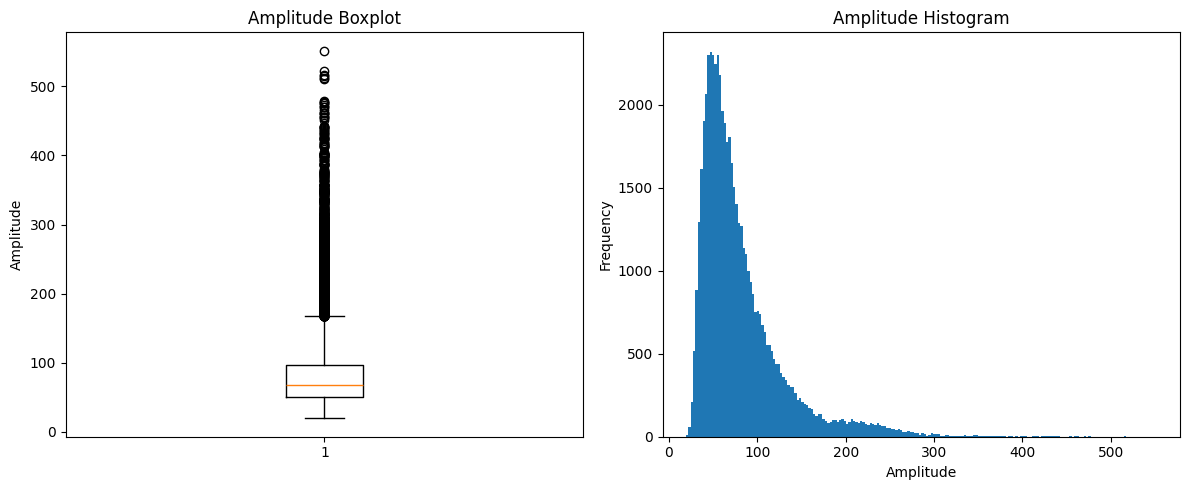

In [79]:
# Plot the distribution of 'amplitudes' in the dataframe
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

#First plot: Boxplot of 'amplitude'
axes[0].boxplot(df['amplitude'])
axes[0].set_title('Amplitude Boxplot')
axes[0].set_ylabel('Amplitude')

# Plot histogram of the column 'amplitude' in the dataframe
axes[1].hist(df['amplitude'], bins=200)
axes[1].set_title('Amplitude Histogram')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
# Save df to csv on Desktop and load df as a pandas dataframe
# df.to_csv(r'C:\Users\Lab admin\Desktop\detections.csv')
# df_compare = pd.read_csv(r'C:\Users\Lab admin\Desktop\detections.csv')

In [11]:
# df_compare = pd.read_pickle(r'C:\Users\Lab admin\Desktop\u-Track3D\testTrackability/OS_41_5-10min-01_processed-cropped_channel3_analysis/detection_results/channel_1_detections.pkl')

In [44]:
# Import two pkl files and compare their detection counts
df_MA2 = pd.read_pickle('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/ch2/detection/channel_1_detections.pkl').reset_index()
df_MA3 = pd.read_pickle('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/ch1/detection/channel_1_detections.pkl').reset_index()

In [45]:
#import the corresponing zarr files
zarr_MA2 = zarr.open('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/zarr_file/all_channels_data', mode='r')
zarr_MA3 = zarr.open('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/zarr_file/all_channels_data', mode='r')

In [46]:
#How many spots are detected in the first frame of each dataframe?
print(f"MA2 detections in frame 0: {len(df_MA2[df_MA2['frame'] == 0])}")
print(f"MA3 detections in frame 0: {len(df_MA3[df_MA3['frame'] == 0])}")

MA2 detections in frame 0: 2907
MA3 detections in frame 0: 1872


In [69]:
# ==============================================================================
# SETUP - Define parameters
# ==============================================================================

# Voxel sizes
voxel_size_x = 0.145  # microns
voxel_size_y = 0.145  # microns
voxel_size_z = 0.145  # microns

# Y range correction - use middle 2/3 of the image (centered)
y_fraction = .6

# Amplitude threshold for positive spots
amplitude_threshold = 0

print("="*80)
print("COMPARISON: MA2 vs MA3 - FRAME 0 ONLY")
print("="*80)

COMPARISON: MA2 vs MA3 - FRAME 0 ONLY


In [70]:



# ==============================================================================
# FUNCTION TO ANALYZE A SINGLE DATASET
# ==============================================================================

def analyze_dataset(df, zarr_array, dataset_name, voxel_x, voxel_y, voxel_z, y_frac, amp_threshold):
    """
    Analyze a single dataset for frame 0
    
    Returns: dict with all metrics
    """
    print(f"\n{'='*80}")
    print(f"Analyzing {dataset_name}")
    print(f"{'='*80}")
    
    # Get dimensions
    print(f"\nZarr array shape: {zarr_array.shape}")
    print(f"Dimensions: T={zarr_array.shape[0]}, C={zarr_array.shape[1]}, Z={zarr_array.shape[2]}, Y={zarr_array.shape[3]}, X={zarr_array.shape[4]}")
    
    # Calculate volume dimensions
    full_x_um = zarr_array.shape[4] * voxel_x
    full_z_um = zarr_array.shape[2] * voxel_z
    
    # Calculate CENTERED Y range (middle 2/3)
    y_pixels_total = zarr_array.shape[3]
    y_pixels_to_use = int(y_pixels_total * y_frac)
    
    # Center the range
    y_min_pixel = int((y_pixels_total - y_pixels_to_use) / 2)
    y_max_pixel = y_min_pixel + y_pixels_to_use
    
    corrected_y_um = y_pixels_to_use * voxel_y
    
    # Calculate corrected volume
    corrected_volume_um3 = full_x_um * corrected_y_um * full_z_um
    
    print(f"\nVolume dimensions:")
    print(f"  X: {full_x_um:.2f} µm ({zarr_array.shape[4]} pixels)")
    print(f"  Y: {corrected_y_um:.2f} µm ({y_pixels_to_use} pixels, CENTERED from {y_min_pixel} to {y_max_pixel})")
    print(f"  Z: {full_z_um:.2f} µm ({zarr_array.shape[2]} pixels)")
    print(f"  Corrected volume: {corrected_volume_um3:.2f} µm³")
    
    # FIXED: Get ALL rows where frame COLUMN == 0 (not index)
    df_frame0 = df[df['frame'] == 0]
    
    print(f"\nFrame 0 total detections: {len(df_frame0)}")
    print(f"Y coordinate range in data: {df_frame0['mu_y'].min():.1f} - {df_frame0['mu_y'].max():.1f}")
    
    # Filter to corrected Y range
    df_corrected = df_frame0[(df_frame0['mu_y'] >= y_min_pixel) & (df_frame0['mu_y'] <= y_max_pixel)]
    
    print(f"Detections in corrected Y range ({y_min_pixel} to {y_max_pixel}): {len(df_corrected)}")
    print(f"  Percentage kept: {len(df_corrected)/len(df_frame0)*100:.1f}%")
    
    # Calculate detection density
    num_detections = len(df_corrected)
    density = num_detections / corrected_volume_um3
    
    print(f"\nDetection density:")
    print(f"  {density:.6f} detections/µm³")
    print(f"  {density*1000:.3f} detections/1000µm³")
    
    # Calculate background of the image (using zarr array frame 0)
    channel_idx = 0
    image_frame0 = zarr_array[0, channel_idx, :, y_min_pixel:y_max_pixel, :]
    
    # Calculate background as 10th percentile of the image
    background_10percentile = np.percentile(image_frame0, 10)
    background_mean = np.mean(image_frame0)
    background_median = np.median(image_frame0)
    
    print(f"\nImage background (frame 0, channel {channel_idx}, Y={y_min_pixel}-{y_max_pixel}):")
    print(f"  10th percentile: {background_10percentile:.2f}")
    print(f"  Mean: {background_mean:.2f}")
    print(f"  Median: {background_median:.2f}")
    
    # Analyze detected spot amplitudes
    positive_spots = df_corrected[df_corrected['amplitude'] > amp_threshold]
    
    if len(positive_spots) > 0:
        avg_amplitude = positive_spots['amplitude'].mean()
        std_amplitude = positive_spots['amplitude'].std()
        median_amplitude = positive_spots['amplitude'].median()
        
        print(f"\nDetected spot intensities (amplitude > {amp_threshold}):")
        print(f"  Count: {len(positive_spots)} ({len(positive_spots)/len(df_corrected)*100:.1f}%)")
        print(f"  Mean: {avg_amplitude:.2f} ± {std_amplitude:.2f}")
        print(f"  Median: {median_amplitude:.2f}")
        print(f"  Range: {positive_spots['amplitude'].min():.2f} - {positive_spots['amplitude'].max():.2f}")
        
        # Signal-to-background ratio
        snr = avg_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        print(f"  Signal-to-Background (vs 10th percentile): {snr:.2f}x")
    else:
        avg_amplitude = np.nan
        std_amplitude = np.nan
        median_amplitude = np.nan
        snr = np.nan
        print(f"\nNo positive spots found (all amplitudes ≤ {amp_threshold})")
    
    # Return all metrics
    return {
        'dataset': dataset_name,
        'num_detections': num_detections,
        'density_per_um3': density,
        'density_per_1000um3': density * 1000,
        'corrected_volume_um3': corrected_volume_um3,
        'background_10percentile': background_10percentile,
        'background_mean': background_mean,
        'background_median': background_median,
        'spot_mean_amplitude': avg_amplitude,
        'spot_std_amplitude': std_amplitude,
        'spot_median_amplitude': median_amplitude,
        'spot_count': len(positive_spots) if len(positive_spots) > 0 else 0,
        'snr': snr
    }


Analyzing MA2

Zarr array shape: (128, 2, 114, 2048, 406)
Dimensions: T=128, C=2, Z=114, Y=2048, X=406

Volume dimensions:
  X: 58.87 µm (406 pixels)
  Y: 237.51 µm (1638 pixels, CENTERED from 205 to 1843)
  Z: 16.53 µm (114 pixels)
  Corrected volume: 231125.99 µm³

Frame 0 total detections: 2907
Y coordinate range in data: 5.9 - 2045.1
Detections in corrected Y range (205 to 1843): 2300
  Percentage kept: 79.1%

Detection density:
  0.009951 detections/µm³
  9.951 detections/1000µm³

Image background (frame 0, channel 0, Y=205-1843):
  10th percentile: 0.00
  Mean: 55.30
  Median: 93.00

Detected spot intensities (amplitude > 0):
  Count: 2300 (100.0%)
  Mean: 83.63 ± 105.70
  Median: 51.91
  Range: 14.25 - 1286.20
  Signal-to-Background (vs 10th percentile): infx

Analyzing MA3

Zarr array shape: (150, 3, 114, 2048, 303)
Dimensions: T=150, C=3, Z=114, Y=2048, X=303

Volume dimensions:
  X: 43.93 µm (303 pixels)
  Y: 237.51 µm (1638 pixels, CENTERED from 205 to 1843)
  Z: 16.53 µm (

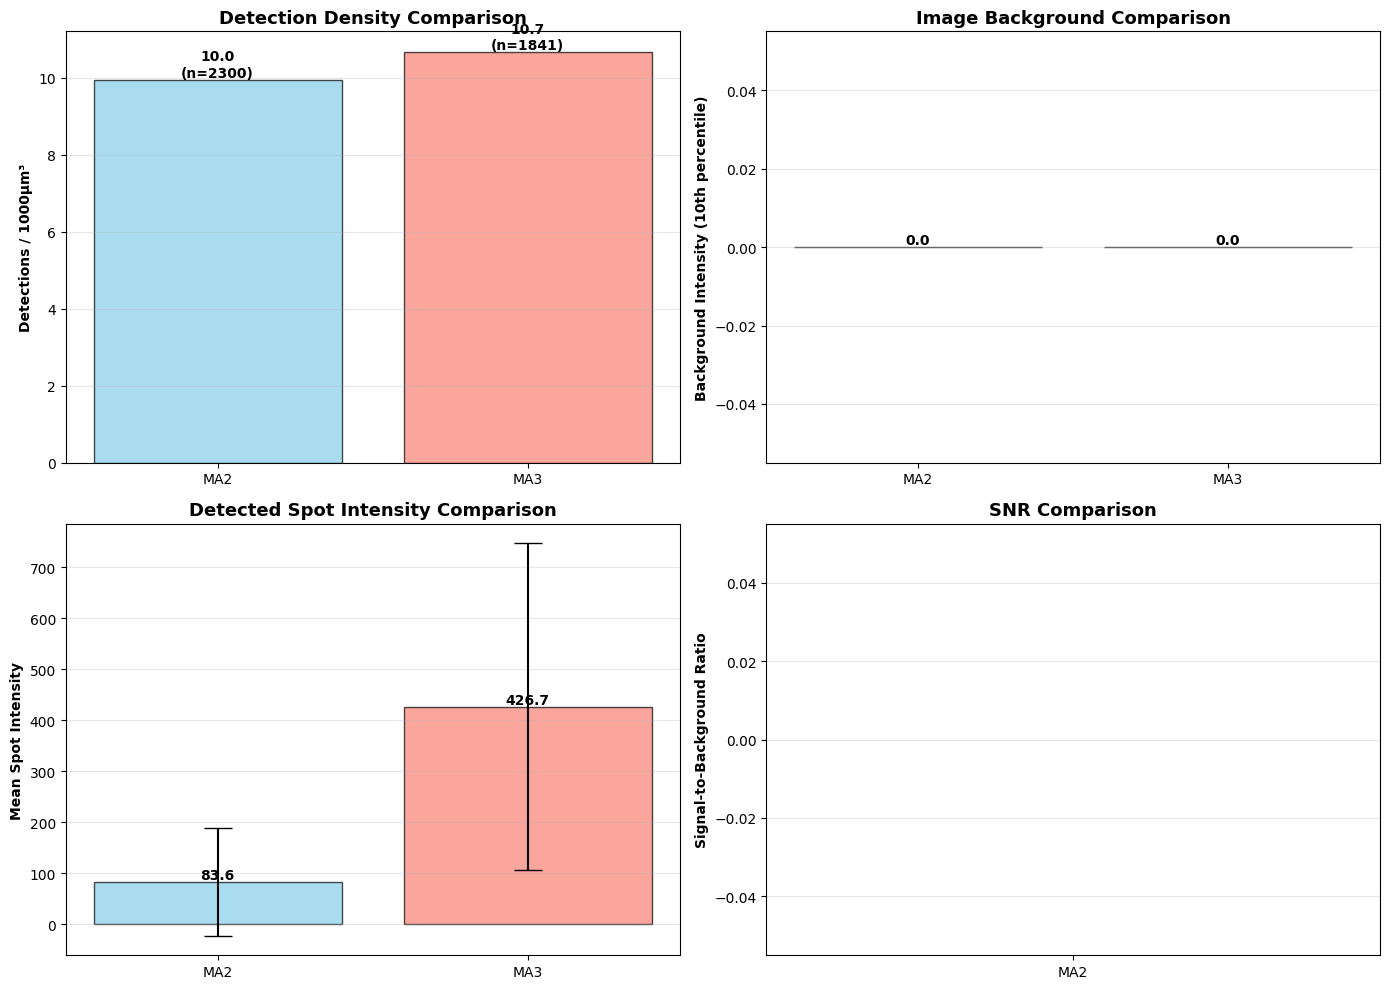


Analysis complete!


In [67]:



# ==============================================================================
# ANALYZE BOTH DATASETS
# ==============================================================================

results_MA2 = analyze_dataset(
    df_MA2, zarr_MA2, 'MA2', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold
)

results_MA3 = analyze_dataset(
    df_MA3, zarr_MA3, 'MA3', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold
)

# ==============================================================================
# COMPARISON SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("COMPARISON SUMMARY - MA2 vs MA3")
print("="*80)

print("\n1. DETECTION DENSITY:")
print(f"   MA2: {results_MA2['density_per_1000um3']:.3f} detections/1000µm³ ({results_MA2['num_detections']} spots)")
print(f"   MA3: {results_MA3['density_per_1000um3']:.3f} detections/1000µm³ ({results_MA3['num_detections']} spots)")
if results_MA2['density_per_1000um3'] > 0:
    fold_density = results_MA3['density_per_1000um3'] / results_MA2['density_per_1000um3']
    print(f"   Fold change (MA3/MA2): {fold_density:.2f}x")

print("\n2. IMAGE BACKGROUND (10th percentile):")
print(f"   MA2: {results_MA2['background_10percentile']:.2f}")
print(f"   MA3: {results_MA3['background_10percentile']:.2f}")
diff_background = results_MA3['background_10percentile'] - results_MA2['background_10percentile']
pct_change = (diff_background / results_MA2['background_10percentile'] * 100) if results_MA2['background_10percentile'] > 0 else 0
print(f"   Difference (MA3-MA2): {diff_background:.2f} ({pct_change:+.1f}%)")

print("\n3. DETECTED SPOT INTENSITY:")
print(f"   MA2: {results_MA2['spot_mean_amplitude']:.2f} ± {results_MA2['spot_std_amplitude']:.2f}")
print(f"   MA3: {results_MA3['spot_mean_amplitude']:.2f} ± {results_MA3['spot_std_amplitude']:.2f}")
if not np.isnan(results_MA2['spot_mean_amplitude']) and not np.isnan(results_MA3['spot_mean_amplitude']):
    fold_intensity = results_MA3['spot_mean_amplitude'] / results_MA2['spot_mean_amplitude']
    print(f"   Fold change (MA3/MA2): {fold_intensity:.2f}x")

print("\n4. SIGNAL-TO-BACKGROUND RATIO:")
print(f"   MA2: {results_MA2['snr']:.2f}x")
print(f"   MA3: {results_MA3['snr']:.2f}x")

print("\n" + "="*80)

# ==============================================================================
# CREATE COMPARISON TABLE
# ==============================================================================

comparison_df = pd.DataFrame([results_MA2, results_MA3])
comparison_df = comparison_df.set_index('dataset')

print("\nDETAILED COMPARISON TABLE:")
print(comparison_df.to_string())

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Detection Density
datasets = ['MA2', 'MA3']
densities = [results_MA2['density_per_1000um3'], results_MA3['density_per_1000um3']]
colors = ['skyblue', 'salmon']

bars = axes[0, 0].bar(datasets, densities, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Detections / 1000µm³', fontweight='bold')
axes[0, 0].set_title('Detection Density Comparison', fontweight='bold', fontsize=13)
axes[0, 0].grid(axis='y', alpha=0.3)

for bar, val, count in zip(bars, densities, [results_MA2['num_detections'], results_MA3['num_detections']]):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}\n(n={count})', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Background Levels
backgrounds = [results_MA2['background_10percentile'], results_MA3['background_10percentile']]

bars = axes[0, 1].bar(datasets, backgrounds, color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Background Intensity (10th percentile)', fontweight='bold')
axes[0, 1].set_title('Image Background Comparison', fontweight='bold', fontsize=13)
axes[0, 1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, backgrounds):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Spot Intensities
spot_intensities = [results_MA2['spot_mean_amplitude'], results_MA3['spot_mean_amplitude']]
spot_stds = [results_MA2['spot_std_amplitude'], results_MA3['spot_std_amplitude']]

bars = axes[1, 0].bar(datasets, spot_intensities, yerr=spot_stds, 
                      color=colors, edgecolor='black', alpha=0.7, capsize=10)
axes[1, 0].set_ylabel('Mean Spot Intensity', fontweight='bold')
axes[1, 0].set_title('Detected Spot Intensity Comparison', fontweight='bold', fontsize=13)
axes[1, 0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, spot_intensities):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Signal-to-Background Ratio
snrs = [results_MA2['snr'], results_MA3['snr']]

bars = axes[1, 1].bar(datasets, snrs, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Signal-to-Background Ratio', fontweight='bold')
axes[1, 1].set_title('SNR Comparison', fontweight='bold', fontsize=13)
axes[1, 1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, snrs):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAnalysis complete!")



Analyzing MA2 - ALL FRAMES

Zarr array shape: (128, 2, 114, 2048, 406)
Dimensions: T=128, C=2, Z=114, Y=2048, X=406

Corrected volume (centered 2/3 in Y):
  X: 58.87 µm
  Y: 178.06 µm (pixels 410-1638)
  Z: 16.53 µm
  Total: 173273.94 µm³

Total frames in dataset: 128
Analyzing frames: 0 to 127

Detection counts per frame:
  Mean: 1525.9 ± 40.5 detections/frame
  Range: 1411 - 1673

Detection density:
  Mean: 0.008807 ± 0.000233 detections/µm³
  Mean: 8.807 ± 0.233 detections/1000µm³
  Range: 8.143 - 9.655 detections/1000µm³

Detected spot intensities (all frames, amplitude > 0):
  Count: 195321 total spots
  Mean: 75.19 ± 90.92
  90th percentile: 143.01

Signal-to-Background Ratios:
  Mean spot / Background: infx
  90th percentile / Background: infx

Analyzing MA3 - ALL FRAMES

Zarr array shape: (150, 3, 114, 2048, 303)
Dimensions: T=150, C=3, Z=114, Y=2048, X=303

Corrected volume (centered 2/3 in Y):
  X: 43.93 µm
  Y: 178.06 µm (pixels 410-1638)
  Z: 16.53 µm
  Total: 129315.28 µm

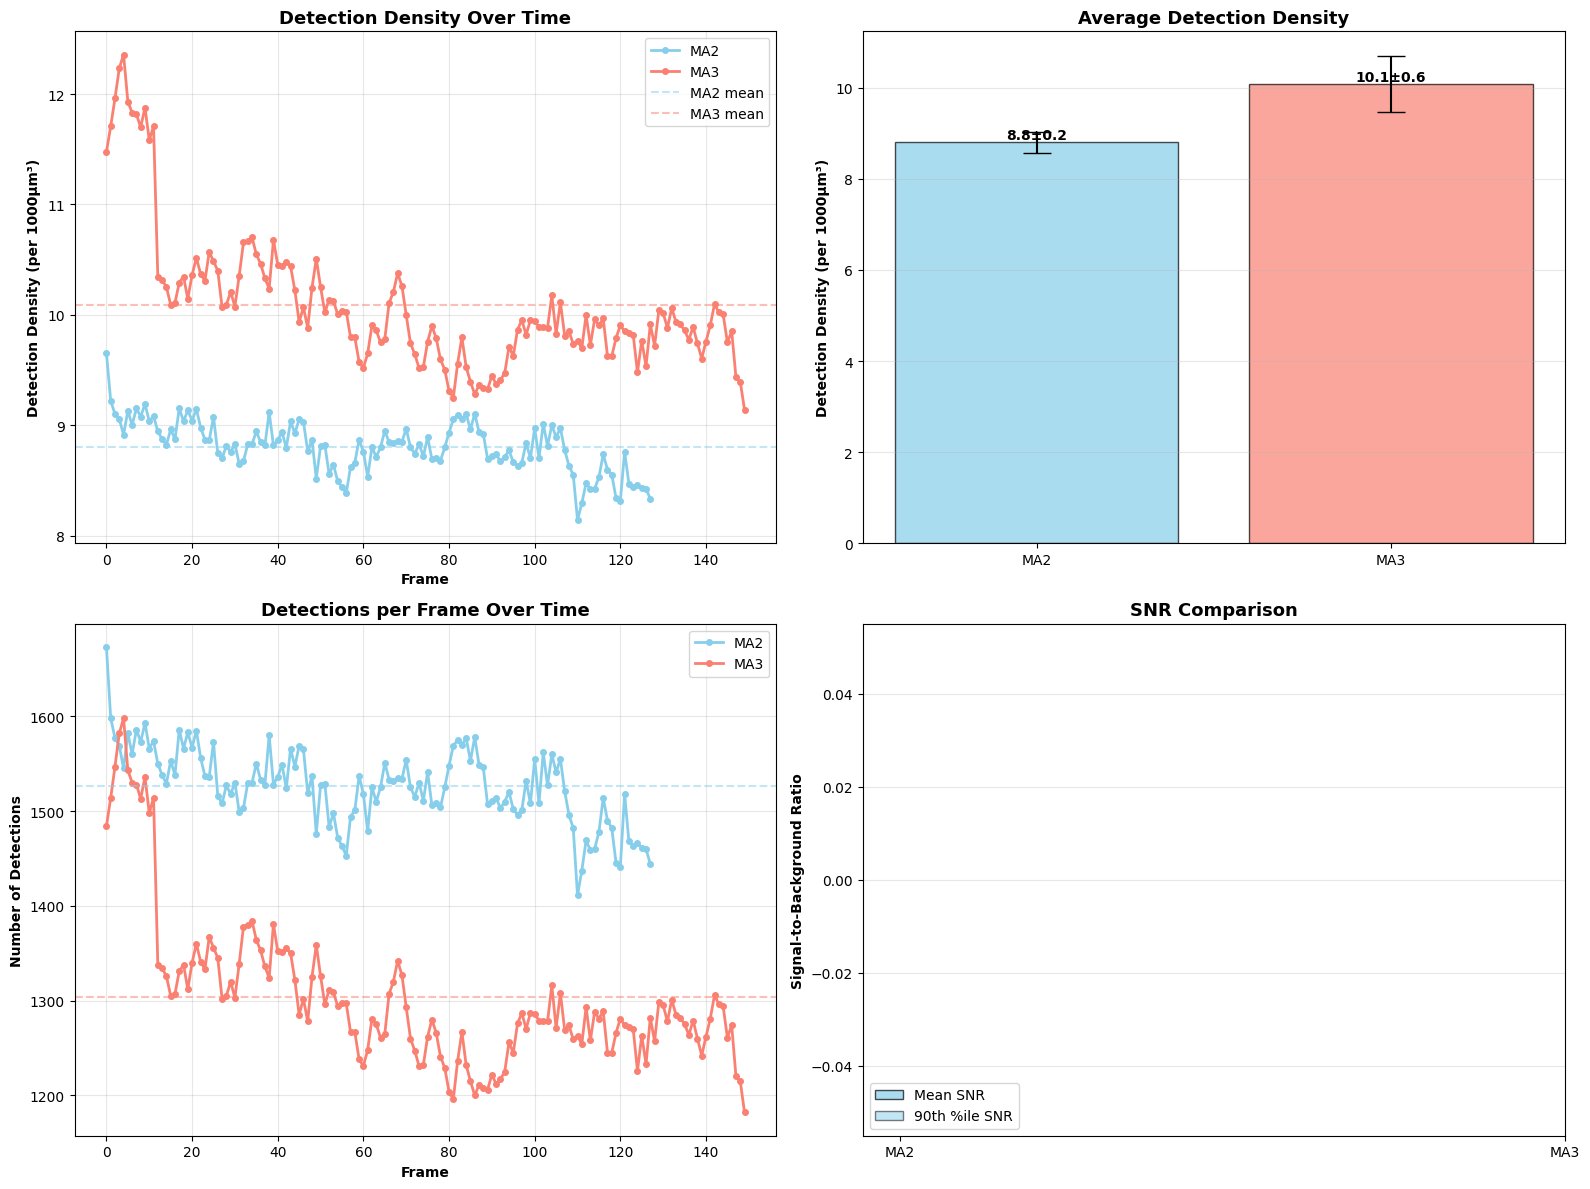


Analysis complete!


In [72]:
def analyze_dataset_all_frames(df, zarr_array, dataset_name, voxel_x, voxel_y, voxel_z, y_frac, amp_threshold):
    """
    Analyze all frames in a dataset and calculate average detection density
    
    Returns: dict with all metrics across all frames
    """
    print(f"\n{'='*80}")
    print(f"Analyzing {dataset_name} - ALL FRAMES")
    print(f"{'='*80}")
    
    # Get dimensions
    print(f"\nZarr array shape: {zarr_array.shape}")
    print(f"Dimensions: T={zarr_array.shape[0]}, C={zarr_array.shape[1]}, Z={zarr_array.shape[2]}, Y={zarr_array.shape[3]}, X={zarr_array.shape[4]}")
    
    # Calculate volume dimensions
    full_x_um = zarr_array.shape[4] * voxel_x
    full_z_um = zarr_array.shape[2] * voxel_z
    
    # Calculate CENTERED Y range (middle 2/3)
    y_pixels_total = zarr_array.shape[3]
    y_pixels_to_use = int(y_pixels_total * y_frac)
    
    # Center the range
    y_min_pixel = int((y_pixels_total - y_pixels_to_use) / 2)
    y_max_pixel = y_min_pixel + y_pixels_to_use
    
    corrected_y_um = y_pixels_to_use * voxel_y
    
    # Calculate corrected volume
    corrected_volume_um3 = full_x_um * corrected_y_um * full_z_um
    
    print(f"\nCorrected volume (centered 2/3 in Y):")
    print(f"  X: {full_x_um:.2f} µm")
    print(f"  Y: {corrected_y_um:.2f} µm (pixels {y_min_pixel}-{y_max_pixel})")
    print(f"  Z: {full_z_um:.2f} µm")
    print(f"  Total: {corrected_volume_um3:.2f} µm³")
    
    # Get all unique frames
    frames = sorted(df['frame'].unique())
    num_frames = len(frames)
    
    print(f"\nTotal frames in dataset: {num_frames}")
    print(f"Analyzing frames: {frames[0]} to {frames[-1]}")
    
    # Arrays to store per-frame metrics
    densities = []
    detection_counts = []
    
    # Loop through each frame
    for frame_num in frames:
        # Get detections for this frame
        df_frame = df[df['frame'] == frame_num]
        
        # Filter to corrected Y range
        df_corrected = df_frame[(df_frame['mu_y'] >= y_min_pixel) & (df_frame['mu_y'] <= y_max_pixel)]
        
        # Count detections
        num_detections = len(df_corrected)
        detection_counts.append(num_detections)
        
        # Calculate density for this frame
        density = num_detections / corrected_volume_um3
        densities.append(density)
    
    # Convert to numpy arrays for statistics
    densities = np.array(densities)
    detection_counts = np.array(detection_counts)
    
    # Calculate statistics
    avg_density = np.mean(densities)
    std_density = np.std(densities)
    avg_detections = np.mean(detection_counts)
    std_detections = np.std(detection_counts)
    
    print(f"\nDetection counts per frame:")
    print(f"  Mean: {avg_detections:.1f} ± {std_detections:.1f} detections/frame")
    print(f"  Range: {detection_counts.min()} - {detection_counts.max()}")
    
    print(f"\nDetection density:")
    print(f"  Mean: {avg_density:.6f} ± {std_density:.6f} detections/µm³")
    print(f"  Mean: {avg_density*1000:.3f} ± {std_density*1000:.3f} detections/1000µm³")
    print(f"  Range: {densities.min()*1000:.3f} - {densities.max()*1000:.3f} detections/1000µm³")
    
    # Calculate background and spot intensities from frame 0 only
    channel_idx = 0
    image_frame0 = zarr_array[0, channel_idx, :, y_min_pixel:y_max_pixel, :]
    background_10percentile = np.percentile(image_frame0, 10)
    
    # Get all detections in corrected Y range (all frames)
    df_all_corrected = df[(df['mu_y'] >= y_min_pixel) & (df['mu_y'] <= y_max_pixel)]
    positive_spots = df_all_corrected[df_all_corrected['amplitude'] > amp_threshold]
    
    if len(positive_spots) > 0:
        avg_amplitude = positive_spots['amplitude'].mean()
        std_amplitude = positive_spots['amplitude'].std()
        percentile_90_amplitude = positive_spots['amplitude'].quantile(0.90)
        
        print(f"\nDetected spot intensities (all frames, amplitude > {amp_threshold}):")
        print(f"  Count: {len(positive_spots)} total spots")
        print(f"  Mean: {avg_amplitude:.2f} ± {std_amplitude:.2f}")
        print(f"  90th percentile: {percentile_90_amplitude:.2f}")
        
        snr_mean = avg_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        snr_90percentile = percentile_90_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        
        print(f"\nSignal-to-Background Ratios:")
        print(f"  Mean spot / Background: {snr_mean:.2f}x")
        print(f"  90th percentile / Background: {snr_90percentile:.2f}x")
    else:
        avg_amplitude = np.nan
        std_amplitude = np.nan
        percentile_90_amplitude = np.nan
        snr_mean = np.nan
        snr_90percentile = np.nan
    
    # Return all metrics
    return {
        'dataset': dataset_name,
        'num_frames': num_frames,
        'avg_detections_per_frame': avg_detections,
        'std_detections_per_frame': std_detections,
        'avg_density_per_um3': avg_density,
        'std_density_per_um3': std_density,
        'avg_density_per_1000um3': avg_density * 1000,
        'std_density_per_1000um3': std_density * 1000,
        'corrected_volume_um3': corrected_volume_um3,
        'background_10percentile': background_10percentile,
        'spot_mean_amplitude': avg_amplitude,
        'spot_std_amplitude': std_amplitude,
        'spot_90percentile_amplitude': percentile_90_amplitude,
        'snr_mean': snr_mean,
        'snr_90percentile': snr_90percentile,
        'densities_per_frame': densities,  # Array of densities for plotting
        'detection_counts_per_frame': detection_counts  # Array of counts for plotting
    }

# ==============================================================================
# ANALYZE BOTH DATASETS (ALL FRAMES)
# ==============================================================================

results_MA2 = analyze_dataset_all_frames(
    df_MA2, zarr_MA2, 'MA2', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold
)

results_MA3 = analyze_dataset_all_frames(
    df_MA3, zarr_MA3, 'MA3', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold
)

# ==============================================================================
# COMPARISON SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("COMPARISON SUMMARY - MA2 vs MA3 (ALL FRAMES)")
print("="*80)

print("\n1. DETECTION DENSITY (AVERAGE ACROSS ALL FRAMES):")
print(f"   MA2: {results_MA2['avg_density_per_1000um3']:.3f} ± {results_MA2['std_density_per_1000um3']:.3f} detections/1000µm³")
print(f"   MA3: {results_MA3['avg_density_per_1000um3']:.3f} ± {results_MA3['std_density_per_1000um3']:.3f} detections/1000µm³")
if results_MA2['avg_density_per_1000um3'] > 0:
    fold_density = results_MA3['avg_density_per_1000um3'] / results_MA2['avg_density_per_1000um3']
    print(f"   Fold change (MA3/MA2): {fold_density:.2f}x")

print("\n2. DETECTIONS PER FRAME:")
print(f"   MA2: {results_MA2['avg_detections_per_frame']:.1f} ± {results_MA2['std_detections_per_frame']:.1f} spots/frame")
print(f"   MA3: {results_MA3['avg_detections_per_frame']:.1f} ± {results_MA3['std_detections_per_frame']:.1f} spots/frame")

print("\n3. BACKGROUND & SPOT INTENSITIES:")
print(f"   MA2 background: {results_MA2['background_10percentile']:.2f}")
print(f"   MA3 background: {results_MA3['background_10percentile']:.2f}")
print(f"   MA2 spot mean: {results_MA2['spot_mean_amplitude']:.2f}")
print(f"   MA3 spot mean: {results_MA3['spot_mean_amplitude']:.2f}")

print("\n4. SIGNAL-TO-BACKGROUND:")
print(f"   MA2: {results_MA2['snr_mean']:.2f}x (mean), {results_MA2['snr_90percentile']:.2f}x (90th percentile)")
print(f"   MA3: {results_MA3['snr_mean']:.2f}x (mean), {results_MA3['snr_90percentile']:.2f}x (90th percentile)")

print("\n" + "="*80)

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Density per frame over time
axes[0, 0].plot(results_MA2['densities_per_frame'] * 1000, 'o-', label='MA2', color='skyblue', linewidth=2, markersize=4)
axes[0, 0].plot(results_MA3['densities_per_frame'] * 1000, 'o-', label='MA3', color='salmon', linewidth=2, markersize=4)
axes[0, 0].axhline(results_MA2['avg_density_per_1000um3'], color='skyblue', linestyle='--', alpha=0.5, label='MA2 mean')
axes[0, 0].axhline(results_MA3['avg_density_per_1000um3'], color='salmon', linestyle='--', alpha=0.5, label='MA3 mean')
axes[0, 0].set_xlabel('Frame', fontweight='bold')
axes[0, 0].set_ylabel('Detection Density (per 1000µm³)', fontweight='bold')
axes[0, 0].set_title('Detection Density Over Time', fontweight='bold', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Average density comparison
datasets = ['MA2', 'MA3']
avg_densities = [results_MA2['avg_density_per_1000um3'], results_MA3['avg_density_per_1000um3']]
std_densities = [results_MA2['std_density_per_1000um3'], results_MA3['std_density_per_1000um3']]
colors = ['skyblue', 'salmon']

bars = axes[0, 1].bar(datasets, avg_densities, yerr=std_densities, 
                      color=colors, edgecolor='black', alpha=0.7, capsize=10)
axes[0, 1].set_ylabel('Detection Density (per 1000µm³)', fontweight='bold')
axes[0, 1].set_title('Average Detection Density', fontweight='bold', fontsize=13)
axes[0, 1].grid(axis='y', alpha=0.3)

for bar, val, std in zip(bars, avg_densities, std_densities):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}±{std:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 3: Detections per frame
axes[1, 0].plot(results_MA2['detection_counts_per_frame'], 'o-', label='MA2', color='skyblue', linewidth=2, markersize=4)
axes[1, 0].plot(results_MA3['detection_counts_per_frame'], 'o-', label='MA3', color='salmon', linewidth=2, markersize=4)
axes[1, 0].axhline(results_MA2['avg_detections_per_frame'], color='skyblue', linestyle='--', alpha=0.5)
axes[1, 0].axhline(results_MA3['avg_detections_per_frame'], color='salmon', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Frame', fontweight='bold')
axes[1, 0].set_ylabel('Number of Detections', fontweight='bold')
axes[1, 0].set_title('Detections per Frame Over Time', fontweight='bold', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: SNR comparison
snr_means = [results_MA2['snr_mean'], results_MA3['snr_mean']]
snr_90s = [results_MA2['snr_90percentile'], results_MA3['snr_90percentile']]

x = np.arange(len(datasets))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, snr_means, width, label='Mean SNR', 
                       color=colors, edgecolor='black', alpha=0.7)
bars2 = axes[1, 1].bar(x + width/2, snr_90s, width, label='90th %ile SNR',
                       color=colors, edgecolor='black', alpha=0.5)

axes[1, 1].set_ylabel('Signal-to-Background Ratio', fontweight='bold')
axes[1, 1].set_title('SNR Comparison', fontweight='bold', fontsize=13)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(datasets)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalysis complete!")


In [ ]:
base_dir = r'/Volumes/ActiveNAS/abhi/LLSM/2024-07-26_MA3cells/MA3_410_615_510_151515_15um/2'
# Z:\Abhi\LLSM\2024-07-26_MA3cells\MA3_410_615_510_151515_15um\2\20240726_MA3_Abhi410_615_510_151515_15um-02_processed
keywords = ["02_processed"]
destination_dir = r'/Volumes/ActiveNAS/Valerie/TransferFolder/ArpC3Comparison'
channels_to_tiff=[0, 1, 2]
organize_czi_files(base_dir, destination_dir, keywords, channels_to_tiff)

Saved TIFFs for channels [0, 1, 2] to /Volumes/ActiveNAS/Valerie/TransferFolder/ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed
Processed: 20240726_MA3_Abhi410_615_510_151515_15um-02_processed.czi



MA2 Intensity Statistics:
  Total pixels: 63,177,660
  Min: 0.00
  5th percentile: 0.00
  10th percentile: 0.00
  20th percentile: 0.00
  Median: 93.00
  Mean: 55.35
  Max: 1026.00


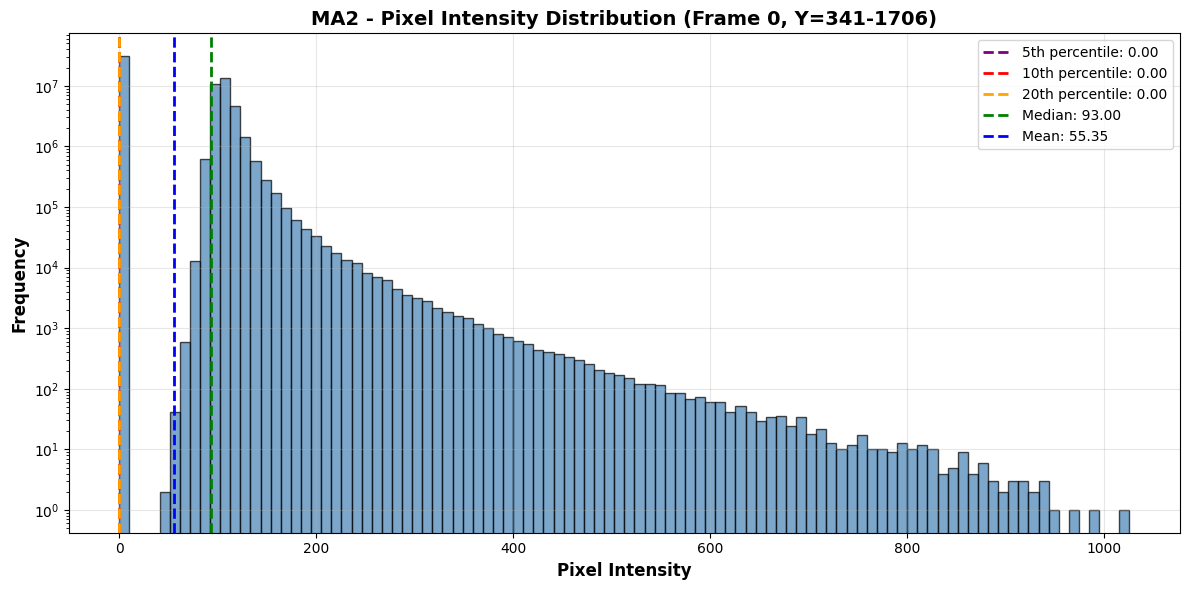


MA3 Intensity Statistics:
  Total pixels: 47,149,830
  Min: 0.00
  5th percentile: 0.00
  10th percentile: 0.00
  20th percentile: 0.00
  Median: 0.00
  Mean: 103.43
  Max: 4995.00


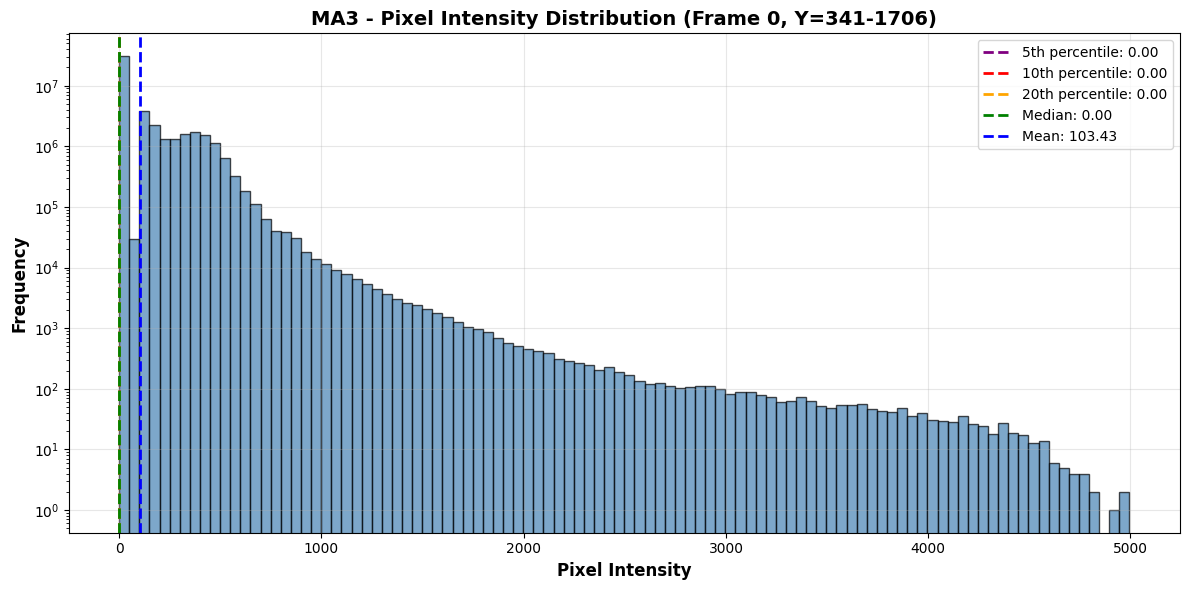

In [53]:

# Function to plot intensity histogram for a dataset
def plot_intensity_histogram(zarr_array, dataset_name, y_min_pixel, y_max_pixel):
    """
    Plot histogram of pixel intensities in frame 0 with background metrics
    """
    # Extract frame 0, channel 0, corrected Y range
    channel_idx = 0
    image_frame0 = zarr_array[0, channel_idx, :, y_min_pixel:y_max_pixel, :]
    
    # Flatten to 1D array of all pixel intensities
    intensities = image_frame0.flatten()
    
    # Calculate background metrics
    background_10percentile = np.percentile(intensities, 10)
    background_5percentile = np.percentile(intensities, 5)
    background_20percentile = np.percentile(intensities, 20)
    background_mean = np.mean(intensities)
    background_median = np.median(intensities)
    
    # Create histogram
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot histogram (use log scale for y-axis to see both background and bright spots)
    ax.hist(intensities, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    
    # Mark background metrics
    ax.axvline(background_5percentile, color='purple', linestyle='--', linewidth=2, 
               label=f'5th percentile: {background_5percentile:.2f}')
    ax.axvline(background_10percentile, color='red', linestyle='--', linewidth=2, 
               label=f'10th percentile: {background_10percentile:.2f}')
    ax.axvline(background_20percentile, color='orange', linestyle='--', linewidth=2, 
               label=f'20th percentile: {background_20percentile:.2f}')
    ax.axvline(background_median, color='green', linestyle='--', linewidth=2, 
               label=f'Median: {background_median:.2f}')
    ax.axvline(background_mean, color='blue', linestyle='--', linewidth=2, 
               label=f'Mean: {background_mean:.2f}')
    
    ax.set_xlabel('Pixel Intensity', fontweight='bold', fontsize=12)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax.set_title(f'{dataset_name} - Pixel Intensity Distribution (Frame 0, Y={y_min_pixel}-{y_max_pixel})', 
                 fontweight='bold', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')  # Log scale to see both background and bright spots
    
    # Print statistics
    print(f"\n{dataset_name} Intensity Statistics:")
    print(f"  Total pixels: {len(intensities):,}")
    print(f"  Min: {intensities.min():.2f}")
    print(f"  5th percentile: {background_5percentile:.2f}")
    print(f"  10th percentile: {background_10percentile:.2f}")
    print(f"  20th percentile: {background_20percentile:.2f}")
    print(f"  Median: {background_median:.2f}")
    print(f"  Mean: {background_mean:.2f}")
    print(f"  Max: {intensities.max():.2f}")
    
    plt.tight_layout()
    plt.show()

# Calculate Y range (same as in analysis function)
y_fraction = 2/3
y_pixels_total_MA2 = zarr_MA2.shape[3]
y_pixels_to_use = int(y_pixels_total_MA2 * y_fraction)
y_min_pixel = int((y_pixels_total_MA2 - y_pixels_to_use) / 2)
y_max_pixel = y_min_pixel + y_pixels_to_use

# Plot for both datasets
plot_intensity_histogram(zarr_MA2, 'MA2', y_min_pixel, y_max_pixel)
plot_intensity_histogram(zarr_MA3, 'MA3', y_min_pixel, y_max_pixel)


In [74]:
def analyze_dataset(df, zarr_array, dataset_name, voxel_x, voxel_y, voxel_z, y_frac, amp_threshold):
    """
    Analyze a single dataset for frame 0
    
    Returns: dict with all metrics
    """
    print(f"\n{'='*80}")
    print(f"Analyzing {dataset_name}")
    print(f"{'='*80}")
    
    # Get dimensions
    print(f"\nZarr array shape: {zarr_array.shape}")
    print(f"Dimensions: T={zarr_array.shape[0]}, C={zarr_array.shape[1]}, Z={zarr_array.shape[2]}, Y={zarr_array.shape[3]}, X={zarr_array.shape[4]}")
    
    # Calculate volume dimensions
    full_x_um = zarr_array.shape[4] * voxel_x
    full_z_um = zarr_array.shape[2] * voxel_z
    
    # Calculate CENTERED Y range (middle 2/3)
    y_pixels_total = zarr_array.shape[3]
    y_pixels_to_use = int(y_pixels_total * y_frac)
    
    # Center the range
    y_min_pixel = int((y_pixels_total - y_pixels_to_use) / 2)
    y_max_pixel = y_min_pixel + y_pixels_to_use
    
    corrected_y_um = y_pixels_to_use * voxel_y
    
    # Calculate corrected volume
    corrected_volume_um3 = full_x_um * corrected_y_um * full_z_um
    
    print(f"\nVolume dimensions:")
    print(f"  X: {full_x_um:.2f} µm ({zarr_array.shape[4]} pixels)")
    print(f"  Y: {corrected_y_um:.2f} µm ({y_pixels_to_use} pixels, CENTERED from {y_min_pixel} to {y_max_pixel})")
    print(f"  Z: {full_z_um:.2f} µm ({zarr_array.shape[2]} pixels)")
    print(f"  Corrected volume: {corrected_volume_um3:.2f} µm³")
    
    # Get ALL rows where frame COLUMN == 0
    df_frame0 = df[df['frame'] == 0]
    
    print(f"\nFrame 0 total detections: {len(df_frame0)}")
    print(f"Y coordinate range in data: {df_frame0['mu_y'].min():.1f} - {df_frame0['mu_y'].max():.1f}")
    
    # Filter to corrected Y range
    df_corrected = df_frame0[(df_frame0['mu_y'] >= y_min_pixel) & (df_frame0['mu_y'] <= y_max_pixel)]
    
    print(f"Detections in corrected Y range ({y_min_pixel} to {y_max_pixel}): {len(df_corrected)}")
    print(f"  Percentage kept: {len(df_corrected)/len(df_frame0)*100:.1f}%")
    
    # Calculate detection density
    num_detections = len(df_corrected)
    density = num_detections / corrected_volume_um3
    
    print(f"\nDetection density:")
    print(f"  {density:.6f} detections/µm³")
    print(f"  {density*1000:.3f} detections/1000µm³")
    
    # Calculate background of the image (using zarr array frame 0)
    channel_idx = 0
    image_frame0 = zarr_array[0, channel_idx, :, y_min_pixel:y_max_pixel, :]
    
    # Calculate background as 10th percentile of the image
    background_10percentile = np.percentile(image_frame0, 10)
    background_mean = np.mean(image_frame0)
    background_median = np.median(image_frame0)
    
    print(f"\nImage background (frame 0, channel {channel_idx}, Y={y_min_pixel}-{y_max_pixel}):")
    print(f"  10th percentile: {background_10percentile:.2f}")
    print(f"  Mean: {background_mean:.2f}")
    print(f"  Median: {background_median:.2f}")
    
    # Analyze detected spot amplitudes
    positive_spots = df_corrected[df_corrected['amplitude'] > amp_threshold]
    
    if len(positive_spots) > 0:
        avg_amplitude = positive_spots['amplitude'].mean()
        std_amplitude = positive_spots['amplitude'].std()
        median_amplitude = positive_spots['amplitude'].median()
        percentile_90_amplitude = positive_spots['amplitude'].quantile(0.90)
        percentile_75_amplitude = positive_spots['amplitude'].quantile(0.75)
        percentile_25_amplitude = positive_spots['amplitude'].quantile(0.25)
        
        print(f"\nDetected spot intensities (amplitude > {amp_threshold}):")
        print(f"  Count: {len(positive_spots)} ({len(positive_spots)/len(df_corrected)*100:.1f}%)")
        print(f"  Mean: {avg_amplitude:.2f} ± {std_amplitude:.2f}")
        print(f"  Median: {median_amplitude:.2f}")
        print(f"  25th percentile: {percentile_25_amplitude:.2f}")
        print(f"  75th percentile: {percentile_75_amplitude:.2f}")
        print(f"  90th percentile: {percentile_90_amplitude:.2f}")
        print(f"  Range: {positive_spots['amplitude'].min():.2f} - {positive_spots['amplitude'].max():.2f}")
        
        # Signal-to-background ratios
        snr_mean = avg_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        snr_90percentile = percentile_90_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        
        print(f"\nSignal-to-Background Ratios:")
        print(f"  Mean spot / Background: {snr_mean:.2f}x")
        print(f"  90th percentile spot / Background: {snr_90percentile:.2f}x")
    else:
        avg_amplitude = np.nan
        std_amplitude = np.nan
        median_amplitude = np.nan
        percentile_90_amplitude = np.nan
        snr_mean = np.nan
        snr_90percentile = np.nan
        print(f"\nNo positive spots found (all amplitudes ≤ {amp_threshold})")
    
    # Return all metrics
    return {
        'dataset': dataset_name,
        'num_detections': num_detections,
        'density_per_um3': density,
        'density_per_1000um3': density * 1000,
        'corrected_volume_um3': corrected_volume_um3,
        'background_10percentile': background_10percentile,
        'background_mean': background_mean,
        'background_median': background_median,
        'spot_mean_amplitude': avg_amplitude,
        'spot_std_amplitude': std_amplitude,
        'spot_median_amplitude': median_amplitude,
        'spot_90percentile_amplitude': percentile_90_amplitude,
        'spot_count': len(positive_spots) if len(positive_spots) > 0 else 0,
        'snr_mean': snr_mean,
        'snr_90percentile': snr_90percentile
    }


In [75]:
def calculate_lightsheet_mask(zarr_array, frame_idx=0, channel_idx=0, intensity_threshold_percentile=5):
    """
    Create a mask for the light sheet illuminated region
    
    Parameters:
    -----------
    zarr_array : zarr array
        The image data
    frame_idx : int
        Frame to use for calculating mask
    channel_idx : int
        Channel to use
    intensity_threshold_percentile : float
        Percentile threshold to define "illuminated" vs "empty" regions
    
    Returns:
    --------
    mask : 3D boolean array (Z, Y, X)
        True where light sheet illuminates, False in empty regions
    illuminated_volume_fraction : float
        Fraction of volume that is illuminated
    """
    # Get one frame to analyze
    image_data = zarr_array[frame_idx, channel_idx, :, :, :]
    
    # Calculate threshold based on intensity
    threshold = np.percentile(image_data, intensity_threshold_percentile)
    
    # Create mask: True where intensity > threshold
    mask = image_data > threshold
    
    # Calculate fraction of volume that's illuminated
    illuminated_volume_fraction = np.sum(mask) / mask.size
    
    return mask, illuminated_volume_fraction

def analyze_dataset_with_lightsheet_correction(df, zarr_array, dataset_name, voxel_x, voxel_y, voxel_z, 
                                                y_frac, amp_threshold, use_lightsheet_mask=True):
    """
    Analyze all frames with light sheet shape correction
    
    Returns: dict with all metrics across all frames
    """
    print(f"\n{'='*80}")
    print(f"Analyzing {dataset_name} - ALL FRAMES (Light Sheet Corrected)")
    print(f"{'='*80}")
    
    # Get dimensions
    print(f"\nZarr array shape: {zarr_array.shape}")
    
    # Calculate volume dimensions
    full_x_um = zarr_array.shape[4] * voxel_x
    full_z_um = zarr_array.shape[2] * voxel_z
    
    # Calculate CENTERED Y range (middle portion)
    y_pixels_total = zarr_array.shape[3]
    y_pixels_to_use = int(y_pixels_total * y_frac)
    y_min_pixel = int((y_pixels_total - y_pixels_to_use) / 2)
    y_max_pixel = y_min_pixel + y_pixels_to_use
    corrected_y_um = y_pixels_to_use * voxel_y
    
    # Calculate light sheet mask
    if use_lightsheet_mask:
        print("\nCalculating light sheet illumination mask...")
        mask, illuminated_fraction = calculate_lightsheet_mask(zarr_array, frame_idx=0, channel_idx=0)
        
        # Apply Y range restriction to mask
        mask_corrected = mask[:, y_min_pixel:y_max_pixel, :]
        
        # Calculate illuminated volume in microns^3
        illuminated_voxels = np.sum(mask_corrected)
        voxel_volume_um3 = voxel_x * voxel_y * voxel_z
        illuminated_volume_um3 = illuminated_voxels * voxel_volume_um3
        
        print(f"  Illuminated region: {illuminated_fraction*100:.1f}% of total volume")
        print(f"  Illuminated voxels in corrected Y range: {illuminated_voxels:,}")
        print(f"  Illuminated volume: {illuminated_volume_um3:.2f} µm³")
    else:
        # Use full rectangular volume
        illuminated_volume_um3 = full_x_um * corrected_y_um * full_z_um
        print(f"\nUsing full rectangular volume (no light sheet correction)")
        print(f"  Volume: {illuminated_volume_um3:.2f} µm³")
    
    print(f"\nY range: {y_min_pixel} to {y_max_pixel} pixels ({corrected_y_um:.2f} µm)")
    
    # Get all unique frames
    frames = sorted(df['frame'].unique())
    num_frames = len(frames)
    
    print(f"\nTotal frames: {num_frames}")
    
    # Arrays to store per-frame metrics
    densities = []
    detection_counts = []
    
    # Loop through each frame
    for frame_num in frames:
        # Get detections for this frame
        df_frame = df[df['frame'] == frame_num]
        
        # Filter to corrected Y range
        df_corrected = df_frame[(df_frame['mu_y'] >= y_min_pixel) & (df_frame['mu_y'] <= y_max_pixel)]
        
        # Additional filtering: only count detections in illuminated regions
        if use_lightsheet_mask:
            # Check which detections fall in illuminated voxels
            detections_in_lightsheet = []
            for idx, row in df_corrected.iterrows():
                z_idx = int(row['mu_z'])
                y_idx = int(row['mu_y']) - y_min_pixel  # Adjust for cropped Y range
                x_idx = int(row['mu_x'])
                
                # Check bounds
                if 0 <= z_idx < mask_corrected.shape[0] and \
                   0 <= y_idx < mask_corrected.shape[1] and \
                   0 <= x_idx < mask_corrected.shape[2]:
                    if mask_corrected[z_idx, y_idx, x_idx]:
                        detections_in_lightsheet.append(True)
                    else:
                        detections_in_lightsheet.append(False)
                else:
                    detections_in_lightsheet.append(False)
            
            num_detections = sum(detections_in_lightsheet)
        else:
            num_detections = len(df_corrected)
        
        detection_counts.append(num_detections)
        
        # Calculate density for this frame
        density = num_detections / illuminated_volume_um3
        densities.append(density)
    
    # Convert to numpy arrays
    densities = np.array(densities)
    detection_counts = np.array(detection_counts)
    
    # Calculate statistics
    avg_density = np.mean(densities)
    std_density = np.std(densities)
    avg_detections = np.mean(detection_counts)
    std_detections = np.std(detection_counts)
    
    print(f"\nDetection counts per frame:")
    print(f"  Mean: {avg_detections:.1f} ± {std_detections:.1f} detections/frame")
    print(f"  Range: {detection_counts.min()} - {detection_counts.max()}")
    
    print(f"\nDetection density:")
    print(f"  Mean: {avg_density:.6f} ± {std_density:.6f} detections/µm³")
    print(f"  Mean: {avg_density*1000:.3f} ± {std_density*1000:.3f} detections/1000µm³")
    
    # Calculate background and spot intensities
    channel_idx = 0
    image_frame0 = zarr_array[0, channel_idx, :, y_min_pixel:y_max_pixel, :]
    
    if use_lightsheet_mask:
        # Only calculate background from illuminated regions
        background_values = image_frame0[mask_corrected]
        background_10percentile = np.percentile(background_values, 10)
    else:
        background_10percentile = np.percentile(image_frame0, 10)
    
    # Get all detections in corrected Y range
    df_all_corrected = df[(df['mu_y'] >= y_min_pixel) & (df['mu_y'] <= y_max_pixel)]
    positive_spots = df_all_corrected[df_all_corrected['amplitude'] > amp_threshold]
    
    if len(positive_spots) > 0:
        avg_amplitude = positive_spots['amplitude'].mean()
        std_amplitude = positive_spots['amplitude'].std()
        percentile_90_amplitude = positive_spots['amplitude'].quantile(0.90)
        
        print(f"\nSpot intensities (all frames):")
        print(f"  Count: {len(positive_spots)} spots")
        print(f"  Mean: {avg_amplitude:.2f} ± {std_amplitude:.2f}")
        print(f"  90th percentile: {percentile_90_amplitude:.2f}")
        
        print(f"\nBackground: {background_10percentile:.2f}")
        print(f"SNR (mean/background): {avg_amplitude/background_10percentile:.2f}x")
    else:
        avg_amplitude = np.nan
        std_amplitude = np.nan
        percentile_90_amplitude = np.nan
    
    return {
        'dataset': dataset_name,
        'num_frames': num_frames,
        'avg_detections_per_frame': avg_detections,
        'std_detections_per_frame': std_detections,
        'avg_density_per_um3': avg_density,
        'std_density_per_um3': std_density,
        'avg_density_per_1000um3': avg_density * 1000,
        'std_density_per_1000um3': std_density * 1000,
        'illuminated_volume_um3': illuminated_volume_um3,
        'background_10percentile': background_10percentile,
        'spot_mean_amplitude': avg_amplitude,
        'spot_90percentile_amplitude': percentile_90_amplitude,
        'densities_per_frame': densities,
        'detection_counts_per_frame': detection_counts,
        'lightsheet_corrected': use_lightsheet_mask
    }

# ==============================================================================
# RUN ANALYSIS WITH AND WITHOUT LIGHT SHEET CORRECTION
# ==============================================================================

print("="*80)
print("WITHOUT LIGHT SHEET CORRECTION")
print("="*80)

results_MA2_no_correction = analyze_dataset_with_lightsheet_correction(
    df_MA2, zarr_MA2, 'MA2', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold,
    use_lightsheet_mask=False
)

results_MA3_no_correction = analyze_dataset_with_lightsheet_correction(
    df_MA3, zarr_MA3, 'MA3', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold,
    use_lightsheet_mask=False
)

print("\n\n" + "="*80)
print("WITH LIGHT SHEET CORRECTION")
print("="*80)

results_MA2_corrected = analyze_dataset_with_lightsheet_correction(
    df_MA2, zarr_MA2, 'MA2', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold,
    use_lightsheet_mask=True
)

results_MA3_corrected = analyze_dataset_with_lightsheet_correction(
    df_MA3, zarr_MA3, 'MA3', 
    voxel_size_x, voxel_size_y, voxel_size_z, 
    y_fraction, amplitude_threshold,
    use_lightsheet_mask=True
)

# Compare
print("\n" + "="*80)
print("COMPARISON: WITH vs WITHOUT LIGHT SHEET CORRECTION")
print("="*80)
print(f"\nMA2:")
print(f"  No correction: {results_MA2_no_correction['avg_density_per_1000um3']:.3f} ± {results_MA2_no_correction['std_density_per_1000um3']:.3f} detections/1000µm³")
print(f"  With correction: {results_MA2_corrected['avg_density_per_1000um3']:.3f} ± {results_MA2_corrected['std_density_per_1000um3']:.3f} detections/1000µm³")

print(f"\nMA3:")
print(f"  No correction: {results_MA3_no_correction['avg_density_per_1000um3']:.3f} ± {results_MA3_no_correction['std_density_per_1000um3']:.3f} detections/1000µm³")
print(f"  With correction: {results_MA3_corrected['avg_density_per_1000um3']:.3f} ± {results_MA3_corrected['std_density_per_1000um3']:.3f} detections/1000µm³")


WITHOUT LIGHT SHEET CORRECTION

Analyzing MA2 - ALL FRAMES (Light Sheet Corrected)

Zarr array shape: (128, 2, 114, 2048, 406)

Using full rectangular volume (no light sheet correction)
  Volume: 173273.94 µm³

Y range: 410 to 1638 pixels (178.06 µm)

Total frames: 128

Detection counts per frame:
  Mean: 1525.9 ± 40.5 detections/frame
  Range: 1411 - 1673

Detection density:
  Mean: 0.008807 ± 0.000233 detections/µm³
  Mean: 8.807 ± 0.233 detections/1000µm³

Spot intensities (all frames):
  Count: 195321 spots
  Mean: 75.19 ± 90.92
  90th percentile: 143.01

Background: 0.00
SNR (mean/background): infx

Analyzing MA3 - ALL FRAMES (Light Sheet Corrected)

Zarr array shape: (150, 3, 114, 2048, 303)

Using full rectangular volume (no light sheet correction)
  Volume: 129315.28 µm³

Y range: 410 to 1638 pixels (178.06 µm)

Total frames: 150

Detection counts per frame:
  Mean: 1304.3 ± 80.0 detections/frame
  Range: 1182 - 1598

Detection density:
  Mean: 0.010087 ± 0.000619 detections/µm

/var/folders/0s/t8g59tpd7yv290krn_d3fn1h0000gp/T/ipykernel_28462/3237066490.py:178: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"SNR (mean/background): {avg_amplitude/background_10percentile:.2f}x")



Spot intensities (all frames):
  Count: 195651 spots
  Mean: 405.73 ± 313.34
  90th percentile: 750.17

Background: 0.00
SNR (mean/background): infx


WITH LIGHT SHEET CORRECTION

Analyzing MA2 - ALL FRAMES (Light Sheet Corrected)

Zarr array shape: (128, 2, 114, 2048, 406)

Calculating light sheet illumination mask...


/var/folders/0s/t8g59tpd7yv290krn_d3fn1h0000gp/T/ipykernel_28462/3237066490.py:178: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"SNR (mean/background): {avg_amplitude/background_10percentile:.2f}x")


  Illuminated region: 51.0% of total volume
  Illuminated voxels in corrected Y range: 28,996,764
  Illuminated volume: 88400.26 µm³

Y range: 410 to 1638 pixels (178.06 µm)

Total frames: 128

Detection counts per frame:
  Mean: 1525.9 ± 40.5 detections/frame
  Range: 1411 - 1673

Detection density:
  Mean: 0.017262 ± 0.000458 detections/µm³
  Mean: 17.262 ± 0.458 detections/1000µm³

Spot intensities (all frames):
  Count: 195321 spots
  Mean: 75.19 ± 90.92
  90th percentile: 143.01

Background: 97.00
SNR (mean/background): 0.78x

Analyzing MA3 - ALL FRAMES (Light Sheet Corrected)

Zarr array shape: (150, 3, 114, 2048, 303)

Calculating light sheet illumination mask...
  Illuminated region: 34.5% of total volume
  Illuminated voxels in corrected Y range: 14,640,216
  Illuminated volume: 44632.53 µm³

Y range: 410 to 1638 pixels (178.06 µm)

Total frames: 150

Detection counts per frame:
  Mean: 1304.3 ± 80.0 detections/frame
  Range: 1182 - 1598

Detection density:
  Mean: 0.029224 ± 

In [ ]:
# Create napari visualization to validate the light sheet mask
# This shows frame 0 with the light sheet mask overlay

# Get frame 0 data
frame_idx = 0
channel_idx = 0
image_data = zarr_MA2[frame_idx, channel_idx, :, :, :]

# Create napari viewer
viewer_lightsheet = napari.Viewer()

# Add the raw image data
viewer_lightsheet.add_image(image_data, name='MA2 Frame 0', colormap='gray', blending='translucent')

# Add the light sheet mask as a labels layer with transparency
viewer_lightsheet.add_labels(mask_MA2.astype(int), name='Light Sheet Mask', opacity=0.3)

print("Napari viewer created with light sheet mask overlay")
print("The mask (shown in color) indicates the illuminated light sheet region")
print("Empty/dark regions are excluded from the mask")

NameError: name 'mask_MA2' is not defined

: 